# Low-Rank Entropic Optimal Transport

This notebook generates `fig:low-rank-ot-factorization`.  A nonnegative-rank constraint writes the coupling itself as a composition through a small latent measure,
$$
    P = Q\operatorname{diag}(g)^{-1}R^\top,
    \qquad Q^\top\mathbf 1 = R^\top\mathbf 1 = g.
$$
The factors $Q$ and $R$ are two couplings through an abstract intermediate measure with only $r$ atoms; these atoms are labels, and the latent mass is kept positive and uniform in the numerical experiment.  The notebook solves a deterministic fixed-latent-mass entropic alternating scheme for a one-dimensional mixture example and compares several ranks.  This example is intentionally not ideal for low-rank OT: with a small entropic parameter, the one-dimensional quadratic OT plan is close to a sparse Monge graph, whereas low rank produces a smooth block compression.

In [1]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, PowerNorm, to_rgb

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

FIGURE_NAME = "low-rank-ot-factorization"
OUT = figure_dir(FIGURE_NAME)
THUMB_DIR = FIGROOT / "thumbnails"
THUMB_DIR.mkdir(exist_ok=True)


## Mixture marginals and costs

Both marginals are sampled on the same one-dimensional grid.  The cost is the squared distance, rescaled so that the entropic parameter is easy to read.

In [2]:
def gaussian(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


grid = np.linspace(-3.0, 3.0, 100)
dx = grid[1] - grid[0]

alpha_density = (
    0.45 * gaussian(grid, -1.25, 0.28)
    + 0.35 * gaussian(grid, 0.15, 0.22)
    + 0.20 * gaussian(grid, 1.30, 0.35)
)
beta_density = (
    0.30 * gaussian(grid, -0.75, 0.22)
    + 0.30 * gaussian(grid, 0.85, 0.28)
    + 0.40 * gaussian(grid, 1.85, 0.24)
)
alpha = alpha_density * dx
beta = beta_density * dx
alpha = alpha / alpha.sum()
beta = beta / beta.sum()

C = (grid[:, None] - grid[None, :]) ** 2
C = C / np.percentile(C, 90.0)
EPSILON = 0.006
RANKS = [2, 4, 8, 16]


## Alternating low-rank Sinkhorn updates

For a fixed positive latent mass $g\in\Sigma_r$, the block update in $Q$ is an entropic OT problem between $a$ and $g$ with effective cost $C R\operatorname{diag}(g)^{-1}$.  The update in $R$ is symmetric.  The full low-rank Sinkhorn algorithm can also optimize $g$; here $g$ is kept uniform to keep the figure deterministic and focused on the effect of the intermediate rank.

In [3]:
def sinkhorn_log(a, b, cost, epsilon, *, num_iter=1000):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Sinkhorn did not converge")
        P = ot.sinkhorn(
            a,
            b,
            cost,
            reg=epsilon,
            method="sinkhorn_log",
            numItermax=num_iter,
            stopThr=1e-11,
        )
    return np.asarray(P)


def initialize_factor(marginal, locations, rank, gamma, *, width=0.36):
    centers = np.linspace(np.quantile(locations, 0.08), np.quantile(locations, 0.92), rank)
    weights = np.exp(-0.5 * ((locations[:, None] - centers[None, :]) / width) ** 2) + 1e-9
    factor = marginal[:, None] * weights
    # Iterative proportional fitting gives the requested row and column marginals.
    for _ in range(300):
        factor *= (marginal / np.maximum(factor.sum(axis=1), 1e-300))[:, None]
        factor *= (gamma / np.maximum(factor.sum(axis=0), 1e-300))[None, :]
    return factor


def low_rank_sinkhorn_fixed_gamma(a, b, cost, rank, epsilon, *, n_iter=22):
    gamma = np.ones(rank) / rank
    Q = initialize_factor(a, grid, rank, gamma)
    R = initialize_factor(b, grid, rank, gamma)
    cost_history = []
    for _ in range(n_iter):
        cost_Q = cost @ R / gamma[None, :]
        Q = sinkhorn_log(a, gamma, cost_Q, epsilon, num_iter=800)
        cost_R = cost.T @ Q / gamma[None, :]
        R = sinkhorn_log(b, gamma, cost_R, epsilon, num_iter=800)
        P = (Q / gamma[None, :]) @ R.T
        cost_history.append(float(np.sum(P * cost)))
    P = (Q / gamma[None, :]) @ R.T
    row_error = np.max(np.abs(P.sum(axis=1) - a))
    col_error = np.max(np.abs(P.sum(axis=0) - b))
    if max(row_error, col_error) > 5e-8:
        raise RuntimeError(f"Marginal residual too large: {row_error:.2e}, {col_error:.2e}")
    return P, Q, R, gamma, np.asarray(cost_history)


full_plan = sinkhorn_log(alpha, beta, C, EPSILON, num_iter=2500)
plans = {"full": full_plan}
factors = {}
cost_histories = {}
for rank in RANKS:
    P, Q, R, gamma, cost_history = low_rank_sinkhorn_fixed_gamma(alpha, beta, C, rank, EPSILON)
    plans[rank] = P
    factors[rank] = (Q, R, gamma)
    cost_histories[rank] = cost_history

for key, P in plans.items():
    print(key, "transport cost", float(np.sum(P * C)), "matrix rank", np.linalg.matrix_rank(P, tol=1e-8))


full transport cost 0.07213015883793074 matrix rank 35
2 transport cost 0.09688906784631988 matrix rank 2
4 transport cost 0.07818118272492156 matrix rank 4
8 transport cost 0.07533881307006815 matrix rank 7
16 transport cost 0.07497247265353654 matrix rank 12


## Rendering helpers

The PDF panels have no embedded titles; LaTeX provides the panel labels.  The thumbnail adds short titles only for browsing on GitHub.

In [4]:
plan_cmap = LinearSegmentedColormap.from_list(
    "ot4ml_plan", ["#ffffff", "#ead8ef", "#b984c7", VIOLET, BLUE]
)
plan_vmax = max(np.quantile(P[P > 0], 0.997) for P in plans.values())


def draw_plan(ax, P):
    ax.imshow(
        P,
        origin="lower",
        extent=(grid[0], grid[-1], grid[0], grid[-1]),
        cmap=plan_cmap,
        norm=PowerNorm(gamma=0.55, vmin=0.0, vmax=plan_vmax),
        interpolation="nearest",
        aspect="auto",
    )
    ax.plot([grid[0], grid[-1]], [grid[0], grid[-1]], color="#222222", lw=0.35, alpha=0.25)
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(grid[0], grid[-1])
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.55)
        spine.set_color("#333333")


def top_pairs(matrix, max_pairs=150, rel_threshold=0.018):
    threshold = rel_threshold * matrix.max()
    idx = np.argwhere(matrix >= threshold)
    if len(idx) > max_pairs:
        vals = matrix[idx[:, 0], idx[:, 1]]
        keep = np.argsort(vals)[-max_pairs:]
        idx = idx[keep]
    return [(int(i), int(j), float(matrix[i, j])) for i, j in idx]


def add_weighted_lines(ax, starts, ends, weights, *, color, alpha_scale=0.55, max_width=1.05):
    weights = np.asarray(weights, dtype=float)
    if len(weights) == 0:
        return
    rel = weights / max(weights.max(), 1e-15)
    segments = [[starts[k], ends[k]] for k in range(len(weights))]
    rgb = to_rgb(color)
    colors = [(*rgb, min(0.10 + alpha_scale * r, 0.86)) for r in rel]
    widths = 0.12 + max_width * np.sqrt(rel)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths, zorder=1))


def draw_factor_view(ax, Q, R, gamma):
    y_source, y_latent, y_target = 0.0, 0.52, 1.04
    latent_x = np.linspace(grid[8], grid[-9], len(gamma))

    # Density silhouettes on the source and target lines.
    scale = 0.26 / max(alpha_density.max(), beta_density.max())
    ax.fill_between(grid, y_source, y_source + scale * alpha_density, color=RED, alpha=0.28, linewidth=0)
    ax.plot(grid, y_source + scale * alpha_density, color=RED, lw=0.85)
    ax.fill_between(grid, y_target, y_target - scale * beta_density, color=BLUE, alpha=0.28, linewidth=0)
    ax.plot(grid, y_target - scale * beta_density, color=BLUE, lw=0.85)

    starts, ends, weights = [], [], []
    for i, k, mass in top_pairs(Q, max_pairs=120, rel_threshold=0.020):
        starts.append((grid[i], y_source + scale * alpha_density[i]))
        ends.append((latent_x[k], y_latent))
        weights.append(mass)
    add_weighted_lines(ax, starts, ends, weights, color=RED, alpha_scale=0.33, max_width=0.75)

    starts, ends, weights = [], [], []
    for j, k, mass in top_pairs(R, max_pairs=120, rel_threshold=0.020):
        starts.append((latent_x[k], y_latent))
        ends.append((grid[j], y_target - scale * beta_density[j]))
        weights.append(mass)
    add_weighted_lines(ax, starts, ends, weights, color=BLUE, alpha_scale=0.33, max_width=0.75)

    ax.scatter(latent_x, np.full_like(latent_x, y_latent), s=DIRAC_MARKER_SIZE * 1.15, color=VIOLET, edgecolor="white", linewidth=0.35, zorder=4)
    ax.plot([grid[0], grid[-1]], [y_source, y_source], color="#222222", lw=0.35, alpha=0.35)
    ax.plot([grid[0], grid[-1]], [y_target, y_target], color="#222222", lw=0.35, alpha=0.35)
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(-0.05, 1.10)
    remove_axes(ax)


## Exported panels

In [5]:
# Individual PDFs used by LaTeX.
for name, P in [("full", plans["full"])] + [(f"rank-{rank}", plans[rank]) for rank in RANKS]:
    fig, ax = plt.subplots(figsize=(1.55, 1.45))
    draw_plan(ax, P)
    fig.subplots_adjust(0, 0, 1, 1)
    save_pdf(fig, OUT / f"{name}.pdf", pad_inches=0.018)
    plt.close(fig)

Q4, R4, gamma4 = factors[4]
fig, ax = plt.subplots(figsize=(3.38, 1.45))
draw_factor_view(ax, Q4, R4, gamma4)
fig.subplots_adjust(0, 0, 1, 1)
save_pdf(fig, OUT / "factor-view-r4.pdf", pad_inches=0.018)
plt.close(fig)

# Browser thumbnail with compact titles.
fig = plt.figure(figsize=(9.2, 3.4))
gs = fig.add_gridspec(2, 4, width_ratios=[1.7, 1, 1, 1], height_ratios=[1, 1], wspace=0.18, hspace=0.34)
ax = fig.add_subplot(gs[0, :2])
draw_factor_view(ax, Q4, R4, gamma4)
ax.set_title("latent factorization, r=4", fontsize=8, pad=2)

thumb_panels = [("full", plans["full"]), ("r=2", plans[2]), ("r=4", plans[4]), ("r=8", plans[8]), ("r=16", plans[16])]
positions = [gs[0, 2], gs[0, 3], gs[1, 1], gs[1, 2], gs[1, 3]]
for slot, (title, P) in zip(positions, thumb_panels):
    ax = fig.add_subplot(slot)
    draw_plan(ax, P)
    ax.set_title(title, fontsize=8, pad=2)

ax = fig.add_subplot(gs[1, 0])
ax.plot(RANKS, [np.sum(plans[r] * C) for r in RANKS], color=VIOLET, lw=1.2, marker="o", ms=3)
ax.axhline(np.sum(plans["full"] * C), color=GRAY, lw=0.8, ls="--", alpha=0.8)
ax.set_xticks(RANKS)
ax.set_xlabel("rank", fontsize=7)
ax.set_ylabel("transport cost", fontsize=7)
ax.tick_params(labelsize=7, length=2)
for spine in ax.spines.values():
    spine.set_linewidth(0.55)
fig.savefig(THUMB_DIR / f"{FIGURE_NAME}.png", dpi=190, bbox_inches="tight", pad_inches=0.025, facecolor="white")
plt.close(fig)

print(f"Wrote {OUT}")
print(f"Wrote {THUMB_DIR / (FIGURE_NAME + '.png')}")


Wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/low-rank-ot-factorization
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/low-rank-ot-factorization.png


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

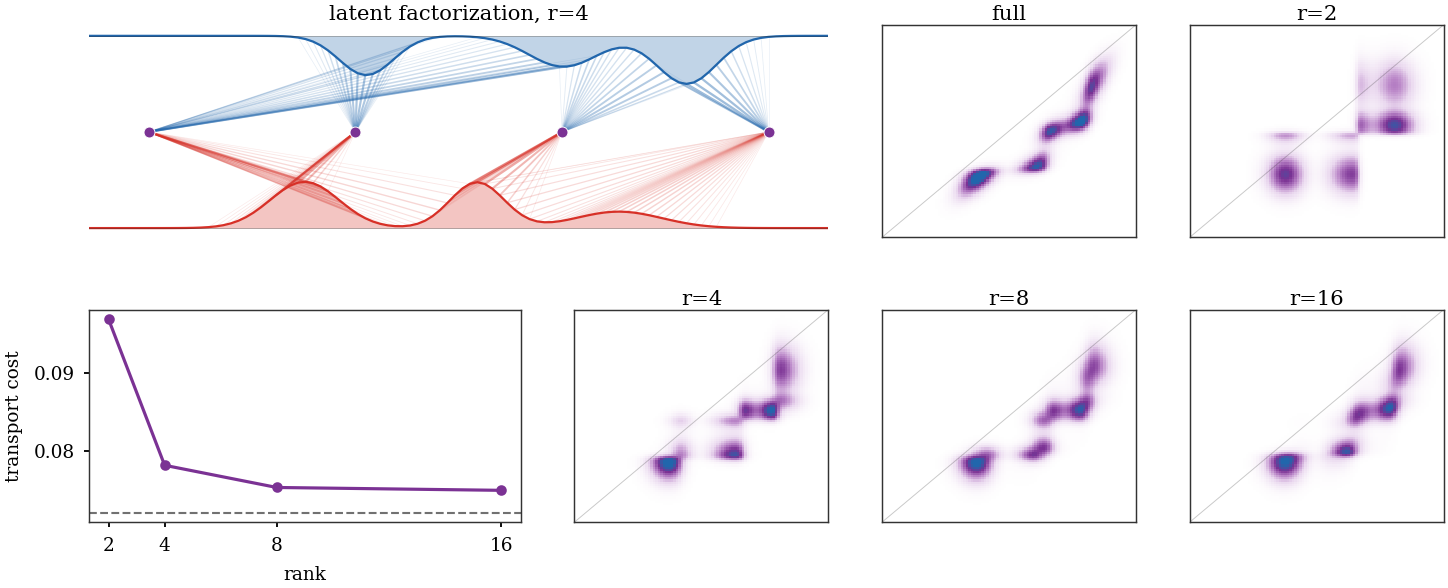

In [6]:
from IPython.display import Image, display

display(Image(filename=str(THUMB_DIR / f"{FIGURE_NAME}.png")))
